# Fase 1 - Ingesta y Perfilado Inicial

El siguiente dataset representa la productividad de equipos de trabajadores en una fábrica de prendas de vestir. Contiene información sobre fechas, departamentos, equipos, trabajadores, tiempos de producción, trabajo en proceso, horas extra, incentivos, interrupciones y productividad objetivo y real. Nuestro objetivo será analizar y mejorar la calidad de estos datos para estudiar qué factores están relacionados con la productividad

## 1.1 Carga del dataset

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/feeerr04/proyecto-da/refs/heads/main/garments_worker_productivity.csv"
df = pd.read_csv(url)

df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.2 Dimensiones del dataset

In [ ]:
df.shape

(1197, 15)

### Interpretación

El conjunto de datos contiene 1,197 observaciones y 15 variables.


## 1.3 Estructura y tipos de datos

In [ ]:
df.columns

Index(['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity',
       'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men',
       'no_of_style_change', 'no_of_workers', 'actual_productivity'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

### Interpretación

El dataset contiene variables de tipo categórico y numérico. Las variables: date, quarter, department y day están almacenadas como texto,
mientras que las demás variables corresponden a datos enteros o decimales.

Se observa además que la variable wip presenta valores faltantes, ya que cuenta con 691 registros no nulos frente a las 1,197 observaciones totales.

### Diccionario de Variables

| Variable | Tipo de dato | Unidad / Escala | Descripción |
|---|---|---|---|
| `date` | Fecha (texto original) | MM-DD-YYYY | Fecha del registro (enero a marzo) |
| `quarter` | Categórica | — | Semana del mes (Quarter1 a Quarter5) |
| `department` | Categórica | — | Departamento de la fábrica (`sweing` o `finishing`) |
| `day` | Categórica | — | Día de la semana |
| `team` | Entero | 1–12 | Número identificador del equipo |
| `targeted_productivity` | Continua | Proporción (0–1) | Productividad objetivo fijada para ese día |
| `smv` | Continua | Minutos | Standard Minute Value: tiempo asignado a la tarea |
| `wip` | Entero | Unidades | Work in Progress: ítems sin terminar (solo aplica al departamento `sweing`) |
| `over_time` | Entero | Minutos | Horas extra trabajadas por el equipo |
| `incentive` | Entero | BDT (taka bangladesí) | Incentivo financiero otorgado al equipo |
| `idle_time` | Continua | Minutos | Tiempo perdido por interrupciones en producción |
| `idle_men` | Entero | Cantidad de trabajadores | Trabajadores inactivos por interrupciones |
| `no_of_style_change` | Entero | Cantidad | Cambios de estilo del producto ese día |
| `no_of_workers` | Continua | Cantidad de trabajadores | Trabajadores asignados al equipo |
| `actual_productivity` | Continua | Proporción (0–1) | Productividad real entregada por el equipo |

## 1.4 Valores faltantes


In [ ]:
df.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


### Interpretación

El análisis muestra que la única variable con valores faltantes es wip, con 506 valores ausentes de un total de 1,197 observaciones. Esto
representa aproximadamente el 42.27% de los registros. Las demás variables no presentan valores faltantes.

Este problema será analizado y tratado posteriormente en la Fase III, donde se justificará el tratamiento seleccionado.

## 1.5 Cardinalidad

In [ ]:
df.nunique()

,0
date,59
quarter,5
department,3
day,6
team,12
targeted_productivity,9
smv,70
wip,548
over_time,143
incentive,48


### Interpretación

La cardinalidad permite identificar la cantidad de valores únicos presentes en cada variable. Se observa que las variables department, day, team y no_of_style_change presentan una cantidad reducida de valores únicos, mientras que variables como wip, over_time y actual_productivity
presentan una mayor variedad de valores.

Esta información permite diferenciar las variables según su nivel de variabilidad y será considerada posteriormente durante el análisis
exploratorio y las transformaciones de los datos.

## 1.6 Registros duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

### Interpretación

El análisis no identificó registros duplicados exactos en el dataset, ya que el resultado obtenido fue 0. Por lo tanto, no es necesario
eliminar registros duplicados como parte del procesamiento inicial.

## Conclusión de la Fase I

El perfilado inicial permitió identificar las principales características y condiciones de calidad del conjunto de datos. El dataset contiene 1,197 observaciones y 15 columnas, por lo que cumple con los requisitos mínimos establecidos para el proyecto.

Se identificaron 506 valores faltantes en la variable wip, mientras que las demás variables no presentan valores ausentes. Además, se observaron diferentes niveles de cardinalidad entre las variables y no se encontraron registros duplicados exactos.

Estos resultados establecen el estado inicial del dataset y servirán como base para las siguientes fases de análisis exploratorio, limpieza y
transformación de los datos.

## Preguntas Analíticas

Antes de iniciar el análisis exploratorio, planteamos las siguientes preguntas que guiarán la exploración de los datos:

1. ¿Qué factores operativos (horas extra, incentivos, número de trabajadores, tiempo de inactividad) están más asociados con la productividad real de los equipos?
2. ¿Existen diferencias sistemáticas de productividad entre los departamentos `sweing` y `finishing`, más allá de la diferencia estructural en el registro de `wip`?
3. ¿La relación entre `wip`/`incentive` y la productividad es más fuerte de lo que sugiere una correlación lineal (Pearson), es decir, sigue un patrón monótono no estrictamente lineal (Spearman)?

# Fase 2 - Análisis Exploratorio de Datos

En esta fase se explorarán las distribuciones de las variables, sus estadísticas descriptivas y las relaciones existentes entre ellas, con
especial atención a las variables relacionadas con la productividad.

## 2.1 Estadísticas descriptivas

In [ ]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


### Interpretación

Las estadísticas descriptivas muestran diferencias importantes en las escalas y variabilidad de las variables numéricas. Por ejemplo, over_time presenta una media de aproximadamente 4,567 minutos y un máximo de 25,920, mientras que incentive presenta una media de aproximadamente 38.21 y un máximo de 3,600.

La variable wip presenta únicamente 691 observaciones disponibles debido a los valores faltantes identificados durante la Fase I. Por esta razón, sus estadísticas descriptivas se calculan sobre los valores no nulos.

Las diferencias observadas entre medias, desviaciones estándar y valores máximos serán consideradas posteriormente en el análisis de distribuciones, detección de valores atípicos y selección de técnicas de transformación.

## 2.2 Distribución de la productividad real

Se analiza la distribución de actual_productivity, variable que representa la productividad real alcanzada por los equipos de trabajo. Se utilizará un histograma acompañado de una estimación de densidad KDE para observar la concentración, dispersión y forma de la distribución.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

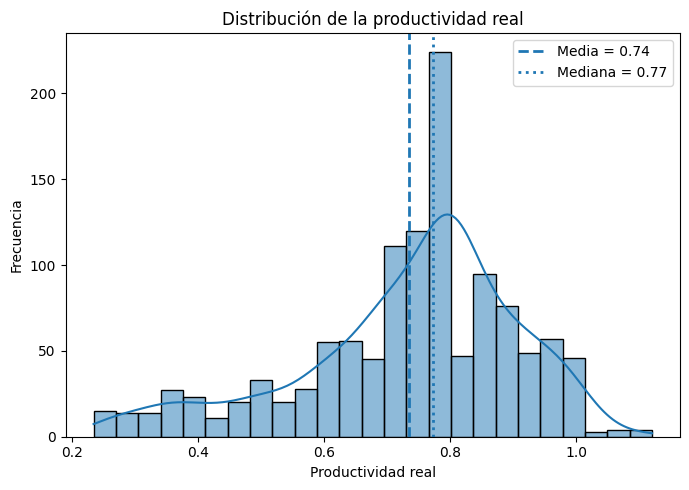

In [ ]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="actual_productivity",
    bins=25,
    kde=True
)

media = df["actual_productivity"].mean()
mediana = df["actual_productivity"].median()

plt.axvline(
    media,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.2f}"
)

plt.axvline(
    mediana,
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {mediana:.2f}"
)

plt.title("Distribución de la productividad real")
plt.xlabel("Productividad real")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

La distribución de actual_productivity muestra una mayor concentración de observaciones en valores cercanos a 0.70–0.85. La media de productividad es 0.74, mientras que la mediana es 0.77, lo que indica que ambas medidas de tendencia central se encuentran relativamente próximas.

También se observa una mayor dispersión hacia valores bajos de productividad, con observaciones aproximadamente desde 0.25, mientras que existen algunos valores superiores a 1.00. Estas observaciones serán consideradas posteriormente durante el análisis de valores atípicos.

La distribución no presenta una forma perfectamente simétrica, por lo que resulta conveniente complementar este análisis visual con otras medidas estadísticas y con la evaluación de valores extremos.

## 2.3 Distribución del tiempo extra de trabajo

Se analiza la distribución de over_tim, variable que representa el tiempo de trabajo extra registrado para los equipos. Su comportamiento puede ayudar a identificar la variabilidad del tiempo adicional de trabajo y posibles
valores extremos que posteriormente serán evaluados.

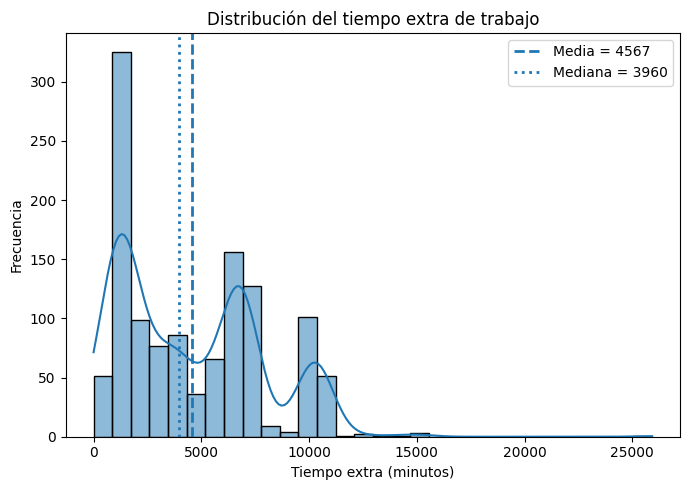

In [ ]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="over_time",
    bins=30,
    kde=True
)

media = df["over_time"].mean()
mediana = df["over_time"].median()

plt.axvline(
    media,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.0f}"
)

plt.axvline(
    mediana,
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {mediana:.0f}"
)

plt.title("Distribución del tiempo extra de trabajo")
plt.xlabel("Tiempo extra (minutos)")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

La variable over_time muestra una marcada concentración de observaciones en valores relativamente bajos, acompañada de una cola larga hacia valores elevados, lo que refleja una distribución asimétrica. La media se sitúa en torno a 4,567 minutos, mientras que la mediana alcanza aproximadamente 3,960 minutos, confirmando el sesgo hacia valores altos.

Se identifican registros que llegan hasta 25,920 minutos, lo cual plantea la necesidad de analizar si corresponden a valores atípicos o si representan condiciones reales del proceso productivo.

El análisis mediante KDE revela múltiples picos en la distribución, lo que indica que el tiempo extra no se concentra en una única zona de valores. Por ello, se prevé un examen adicional de esta variable en relación con actual_productivity, con el fin de determinar si existe algún tipo de asociación entre ambas.

## 2.4 Distribución de los incentivos

Se analiza la distribución de incentive, variable que representa el incentivo económico recibido por los equipos de trabajo. Su comportamiento permite identificar la concentración de los incentivos y posibles valores extremos que deberán ser evaluados posteriormente.

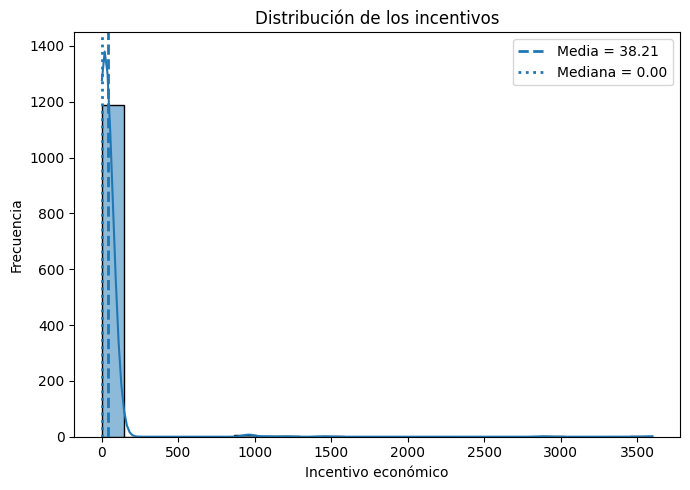

In [ ]:
plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="incentive",
    bins=25,
    kde=True
)

media = df["incentive"].mean()
mediana = df["incentive"].median()

plt.axvline(
    media,
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.2f}"
)

plt.axvline(
    mediana,
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {mediana:.2f}"
)

plt.title("Distribución de los incentivos")
plt.xlabel("Incentivo económico")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

La distribución de incentive presenta una marcada concentración de observaciones en valores iguales o cercanos a cero. La mediana es de 0.00,
mientras que la media alcanza aproximadamente 38.21, lo que indica que los valores elevados tienen influencia sobre el promedio.

La distribución presenta una cola extensa hacia valores altos, con registros que alcanzan aproximadamente 3,600. Estos valores deberán ser evaluados posteriormente para determinar si corresponden a situaciones reales del proceso productivo o si pueden considerarse valores atípicos.

La diferencia entre la media y la mediana muestra que esta variable presenta una distribución fuertemente asimétrica. Posteriormente se analizará su posible relación con actual_productivity.

## 2.5 Productividad real según departamento

Se analiza la productividad real de los equipos según el departamento al que pertenecen. Esta comparación permite observar si existen diferencias en los niveles de productividad entre los distintos departamentos registrados en el dataset.

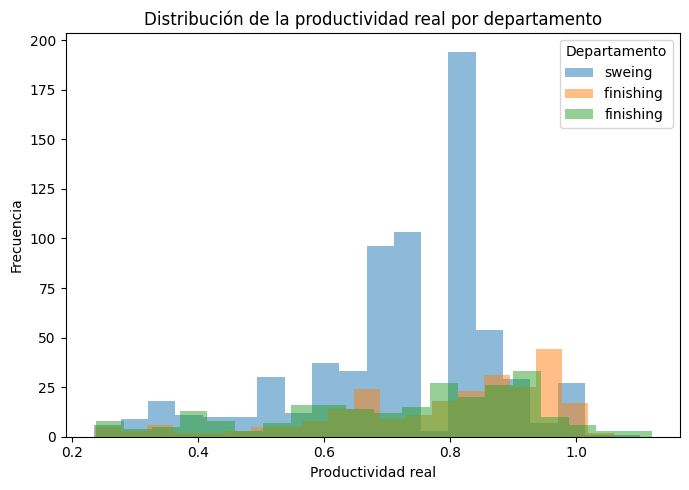

In [ ]:
plt.figure(figsize=(7, 5))

for departamento in df["department"].unique():
    datos = df[df["department"] == departamento]["actual_productivity"]

    plt.hist(
        datos,
        bins=20,
        alpha=0.5,
        label=departamento
    )

plt.title("Distribución de la productividad real por departamento")
plt.xlabel("Productividad real")
plt.ylabel("Frecuencia")
plt.legend(title="Departamento")

plt.tight_layout()
plt.show()

In [ ]:
df["department"].unique()

array(['sweing', 'finishing ', 'finishing'], dtype=object)

### Interpretación

Se identificaron inconsistencias en los valores de la variable department. La categoría finishing aparece registrada con y sin un espacio al final, por lo que el programa las considera como dos categorías diferentes. Esta inconsistencia será corregida posteriormente durante la Fase 3 de limpieza de datos.

## 2.6 Relación entre tiempo extra y productividad

Se analiza la relación entre el tiempo de trabajo extra (over_time) y la productividad real (actual_productivity) para identificar si existe algún patrón entre ambas variables.

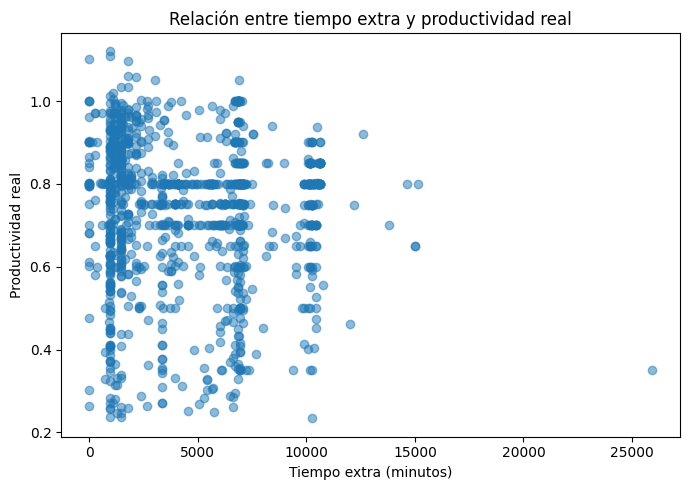

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["over_time"],
    df["actual_productivity"],
    alpha=0.5
)

plt.title("Relación entre tiempo extra y productividad real")
plt.xlabel("Tiempo extra (minutos)")
plt.ylabel("Productividad real")

plt.tight_layout()
plt.show()

### Interpretación

La gráfica muestra una alta dispersión de los valores de productividad para los diferentes niveles de tiempo extra. No se observa visualmente una relación lineal fuerte y clara entre over_time y actual_productivity, ya que para distintos niveles de tiempo extra se presentan valores de productividad tanto altos como bajos.

También se identifican algunos registros con valores de tiempo extra considerablemente elevados, incluyendo observaciones cercanas a 15,000 y
25,920 minutos. Estos valores serán revisados posteriormente durante el análisis de valores atípicos.

La relación entre ambas variables se analizará con mayor detalle mediante medidas estadísticas en las siguientes etapas.

## 2.7 Relación entre incentivos y productividad

Se analiza la relación entre el incentivo económico (incentive) y la productividad real (actual_productivity) para observar si los registros con diferentes niveles de incentivo presentan algún patrón en su productividad.

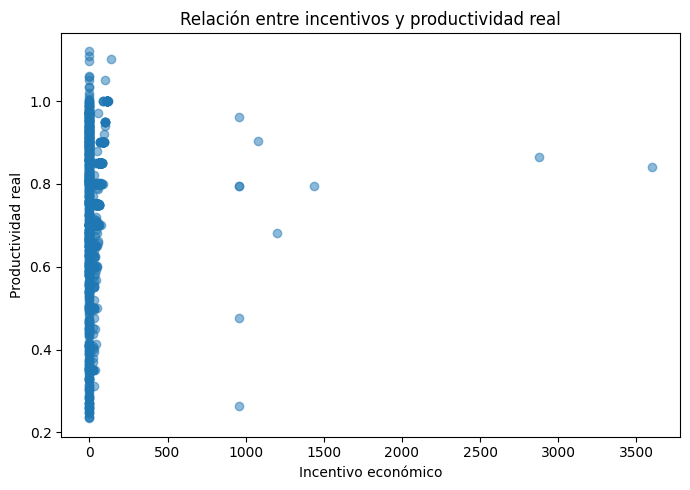

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["incentive"],
    df["actual_productivity"],
    alpha=0.5
)

plt.title("Relación entre incentivos y productividad real")
plt.xlabel("Incentivo económico")
plt.ylabel("Productividad real")

plt.tight_layout()
plt.show()

### Interpretación

La gráfica muestra una fuerte concentración de las observaciones en valores de incentivo iguales o cercanos a cero. Solo una cantidad reducida de registros presenta incentivos considerablemente mayores, llegando hasta aproximadamente 3,600.

Para los valores de incentivo cercanos a cero se observa una amplia dispersión de la productividad real, con registros tanto de productividad baja como alta. Los pocos registros con incentivos elevados también presentan diferentes niveles de productividad, por lo que no se observa visualmente una relación lineal clara entre ambas variables.

La distribución de los incentivos y la presencia de valores elevados serán consideradas posteriormente durante el análisis de valores atípicos.

## 2.8 Relación entre número de trabajadores y productividad

Se analiza la relación entre el número de trabajadores (no_of_workers) y la productividad real (actual_productivity) para observar cómo se distribuye la productividad en equipos con diferentes cantidades de trabajadores.

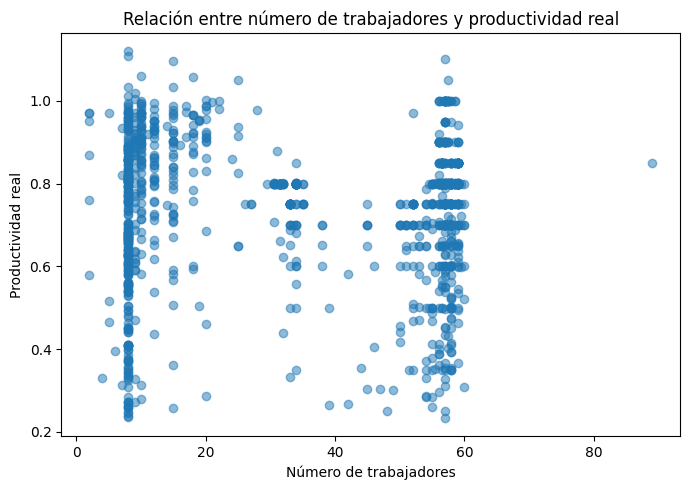

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["no_of_workers"],
    df["actual_productivity"],
    alpha=0.5
)

plt.title("Relación entre número de trabajadores y productividad real")
plt.xlabel("Número de trabajadores")
plt.ylabel("Productividad real")

plt.tight_layout()
plt.show()

### Interpretación

La gráfica muestra que los registros se concentran principalmente en equipos con aproximadamente 10 a 20 trabajadores y en equipos con alrededor de 55 a 60 trabajadores. Dentro de estos grupos se observa una amplia variación en los niveles de productividad real.

No se identifica visualmente una relación lineal clara entre el número de trabajadores y la productividad, ya que diferentes cantidades de trabajadores presentan tanto valores altos como bajos de productividad.

También se observa un registro con aproximadamente 89 trabajadores, alejado de la mayoría de las observaciones. Este valor será considerado posteriormente durante el análisis de valores atípicos.

## 2.9 Relación entre tiempo de inactividad y productividad

Se analiza la relación entre el tiempo de inactividad (idle_time) y la productividad real (actual_productivity) para observar si los registros con mayor tiempo de interrupción presentan algún patrón en su productividad.

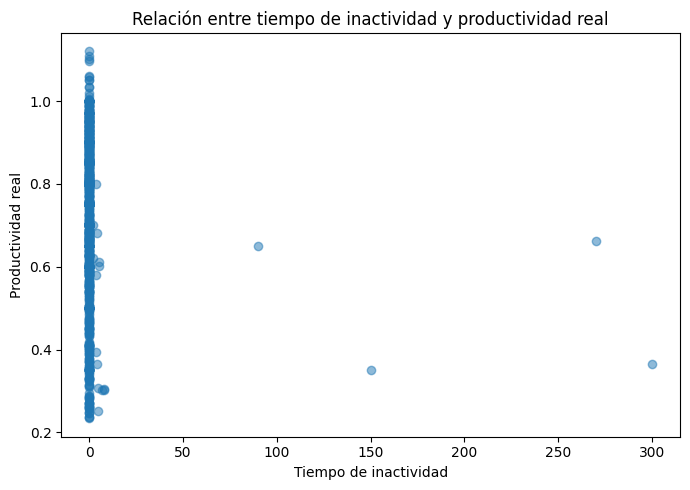

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["idle_time"],
    df["actual_productivity"],
    alpha=0.5
)

plt.title("Relación entre tiempo de inactividad y productividad real")
plt.xlabel("Tiempo de inactividad")
plt.ylabel("Productividad real")

plt.tight_layout()
plt.show()

### Interpretación

La gráfica muestra una fuerte concentración de observaciones con valores de tiempo de inactividad iguales o cercanos a cero. Dentro de este grupo se observa una amplia variación en la productividad real.

También se identifican pocos registros con tiempos de inactividad elevados, que alcanzan aproximadamente 300 unidades. Estos registros presentan niveles de productividad entre bajos y medios.

Visualmente no se identifica una relación lineal clara entre el tiempo de inactividad y la productividad real. Sin embargo, los valores elevados de inactividad constituyen observaciones que deberán revisarse posteriormente durante el análisis de valores atípicos.

## 2.10 Correlación entre variables numéricas

Se analiza la correlación entre las variables numéricas del dataset para identificar posibles asociaciones entre ellas y, especialmente, con la productividad real.

In [ ]:
correlaciones = df.corr(numeric_only=True)

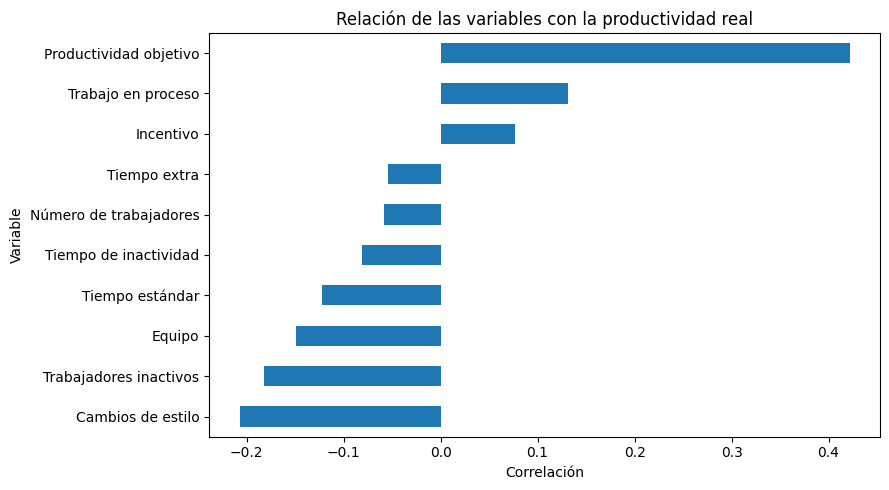

In [ ]:
correlacion_productividad = correlaciones["actual_productivity"].drop("actual_productivity")

nombres_espanol = {
    "team": "Equipo",
    "targeted_productivity": "Productividad objetivo",
    "smv": "Tiempo estándar",
    "wip": "Trabajo en proceso",
    "over_time": "Tiempo extra",
    "incentive": "Incentivo",
    "idle_time": "Tiempo de inactividad",
    "idle_men": "Trabajadores inactivos",
    "no_of_style_change": "Cambios de estilo",
    "no_of_workers": "Número de trabajadores"
}

correlacion_productividad.index = correlacion_productividad.index.map(nombres_espanol)

plt.figure(figsize=(9, 5))

correlacion_productividad.sort_values().plot(kind="barh")

plt.title("Relación de las variables con la productividad real")
plt.xlabel("Correlación")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

### Interpretación

La productividad objetivo presenta la relación positiva más alta con la productividad real, con una correlación aproximada de 0.42.

El trabajo en proceso y el incentivo presentan relaciones positivas débiles. Por otro lado, los cambios de estilo y los trabajadores inactivos muestran relaciones negativas con la productividad real.

En general, la mayoría de las variables presentan correlaciones débiles, por lo que no se observa una relación lineal fuerte entre ellas y la productividad real.

### Correlación de Spearman

Además de la correlación de Pearson (que mide relaciones lineales), se calcula la correlación de Spearman, que evalúa relaciones monótonas (no necesariamente lineales) basándose en el orden de los valores en lugar de su magnitud exacta. Esto es especialmente útil aquí, ya que en la Fase II se observó que varias relaciones (por ejemplo, entre `over_time` y `actual_productivity`) no mostraban un patrón lineal claro, pero podrían presentar una relación monótona no detectada por Pearson.

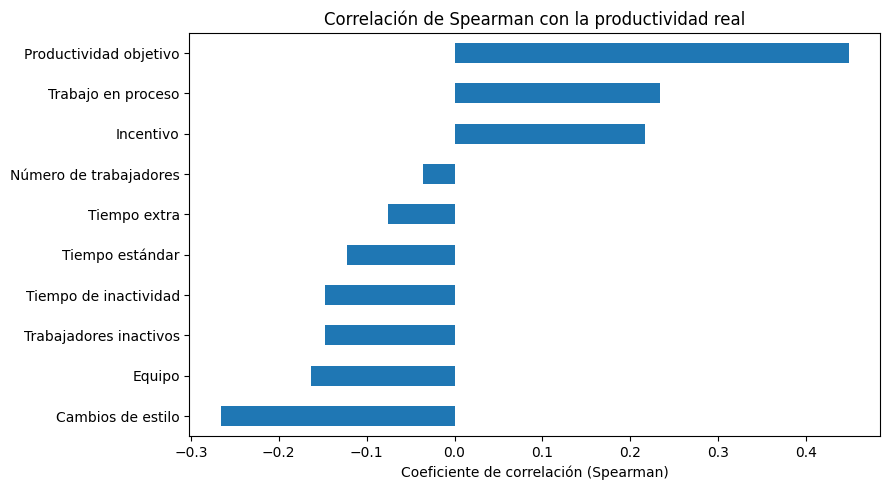

,actual_productivity
Productividad objetivo,0.448375
Trabajo en proceso,0.233244
Incentivo,0.217064
Número de trabajadores,-0.035395
Tiempo extra,-0.075755
Tiempo estándar,-0.122303
Tiempo de inactividad,-0.147596
Trabajadores inactivos,-0.147658
Equipo,-0.163696
Cambios de estilo,-0.265829


In [ ]:
correlaciones_spearman = df.corr(method="spearman", numeric_only=True)

correlacion_productividad_spearman = correlaciones_spearman["actual_productivity"].drop("actual_productivity")
correlacion_productividad_spearman.index = correlacion_productividad_spearman.index.map(nombres_espanol)

plt.figure(figsize=(9, 5))
correlacion_productividad_spearman.sort_values().plot(kind="barh")
plt.title("Correlación de Spearman con la productividad real")
plt.xlabel("Coeficiente de correlación (Spearman)")
plt.tight_layout()
plt.show()

correlacion_productividad_spearman.sort_values(ascending=False)

#### Interpretación: comparación Pearson vs. Spearman

Al comparar ambos coeficientes, se observa que el orden general de importancia se mantiene similar: `targeted_productivity` (productividad objetivo) sigue siendo la variable con mayor asociación positiva con `actual_productivity`, y `no_of_style_change` (cambios de estilo) se mantiene como la relación negativa más marcada en ambos métodos.

Sin embargo, hay diferencias relevantes en la magnitud:

- `wip` (trabajo en proceso) pasa de una correlación positiva débil con Pearson a una correlación de 0.233 con Spearman, notablemente más fuerte. Esto sugiere que la relación entre WIP y productividad no es estrictamente lineal, sino más bien monótona, a medida que aumenta el trabajo en proceso, la productividad tiende a aumentar, pero no de forma proporcional constante.
- `incentive` también muestra un coeficiente de Spearman (0.217) más alto que su contraparte de Pearson, reforzando la idea de que el incentivo económico tiene una relación consistente con la productividad, aunque no lineal, coherente con lo observado en la Fase II (la mayoría de los incentivos se concentran en 0, con una cola de valores altos).

Esto confirma que apoyarse únicamente en Pearson subestimaba la fuerza real de asociación de estas dos variables con la productividad. Para el análisis o modelado posterior, esto sugiere que modelos capaces de capturar relaciones no lineales (como árboles de decisión o ensambles) podrían aprovechar mejor estas variables que un modelo estrictamente lineal.

# Fase 3 - Limpieza y preparación de los datos

## 3.1 Corrección de inconsistencias en las variables categóricas

In [ ]:
df["department"] = df["department"].str.strip()

df["department"].unique()

array(['sweing', 'finishing'], dtype=object)

### Interpretación

Se corrigieron las inconsistencias de formato en la variable department eliminando los espacios innecesarios al inicio y al final de los valores. Después de la limpieza, la variable contiene dos categorías: sweing y finishing.

## 3.2 Tratamiento de valores faltantes

In [ ]:
df.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


### Análisis de los valores faltantes de WIP

In [ ]:
df[df["wip"].isnull()]["department"].value_counts()

,count
department,
finishing,506


In [ ]:
df[df["wip"].isnull()]["team"].value_counts()

,count
team,
8,53
2,52
1,49
4,46
9,46
10,43
7,41
12,40
3,37


In [ ]:
df.groupby("department")["wip"].apply(lambda x: x.notna().sum())

,wip
department,
finishing,0
sweing,691


In [ ]:
df["department"].value_counts()

,count
department,
sweing,691
finishing,506


In [ ]:
df[df["department"] == "finishing"].describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,506.000000,506.000000,506.000000,0.0,506.000000,506.000000,506.0,506.0,506.0,506.000000,506.000000
mean,6.298419,0.737352,3.887036,NaN,1917.154150,29.644269,0.0,0.0,0.0,10.252964,0.752951
std,3.470937,0.091512,0.594110,NaN,1776.698408,244.130042,0.0,0.0,0.0,4.007819,0.197021
min,1.000000,0.350000,2.900000,NaN,0.000000,0.000000,0.0,0.0,0.0,2.000000,0.235795
25%,3.000000,0.700000,3.900000,NaN,960.000000,0.000000,0.0,0.0,0.0,8.000000,0.631606
50%,6.000000,0.750000,3.940000,NaN,1440.000000,0.000000,0.0,0.0,0.0,8.000000,0.805909
75%,9.000000,0.800000,4.150000,NaN,1920.000000,0.000000,0.0,0.0,0.0,11.750000,0.906364
max,12.000000,0.800000,5.130000,NaN,15000.000000,3600.000000,0.0,0.0,0.0,28.000000,1.120437


In [ ]:
df[df["department"] == "sweing"]["wip"].describe()

,wip
count,691.000000
mean,1190.465991
std,1837.455001
min,7.000000
25%,774.500000
50%,1039.000000
75%,1252.500000
max,23122.000000


In [ ]:
df.groupby("department")[["targeted_productivity", "smv", "over_time", "incentive", "no_of_workers", "actual_productivity"]].mean()

,targeted_productivity,smv,over_time,incentive,no_of_workers,actual_productivity
department,,,,,,
finishing,0.737352,3.887036,1917.154150,29.644269,10.252964,0.752951
sweing,0.723980,23.245412,6508.205499,44.483357,52.445731,0.722013


In [ ]:
df.groupby("department")["wip"].apply(lambda x: x.notna().sum())

,wip
department,
finishing,0
sweing,691


### 3.2.1 Decisión sobre los valores faltantes de WIP

Los 506 valores faltantes de la variable WIP corresponden exclusivamente al departamento finishing. En el departamento sweing existen 691 valores registrados de WIP.

Debido a que no existen valores de WIP registrados para finishing, no se imputarán valores utilizando el promedio de otro departamento, ya que ambos departamentos presentan características diferentes. Tampoco se eliminarán estos registros, debido a que representan una parte importante del conjunto de datos.

Por lo tanto, los valores faltantes de WIP se conservarán como valores ausentes y se considerarán faltantes estructurales del conjunto de datos.

## 3.3 Detección de registros duplicados

In [ ]:
df.duplicated().sum()

np.int64(0)

### Interpretación

No se encontraron registros duplicados en el conjunto de datos. Por lo tanto, no fue necesario eliminar observaciones por duplicación.

## 3.4 Detección de valores atípicos

In [ ]:
df[["targeted_productivity", "smv", "wip", "over_time", "incentive", "idle_time", "idle_men", "no_of_style_change", "no_of_workers", "actual_productivity"]].describe()

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


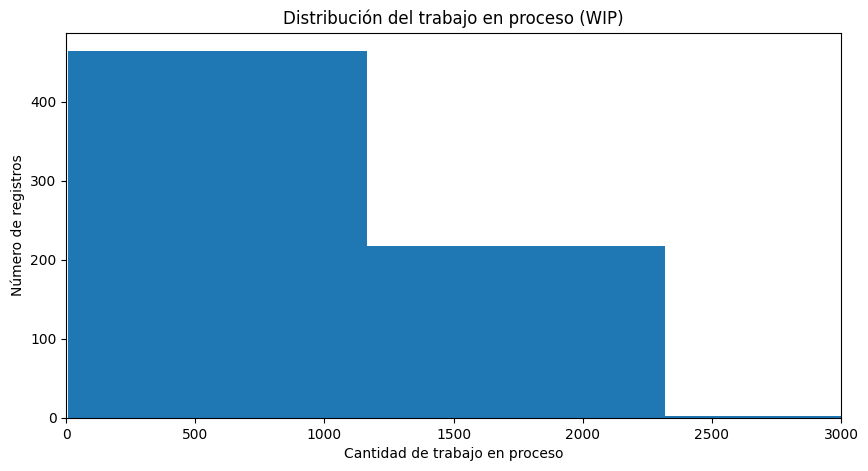

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["wip"].dropna(), bins=20)

plt.xlim(0, 3000)

plt.title("Distribución del trabajo en proceso (WIP)")
plt.xlabel("Cantidad de trabajo en proceso")
plt.ylabel("Número de registros")

plt.show()

### Interpretación

La mayoría de los valores de trabajo en proceso (WIP) se concentran entre 0 y aproximadamente 2,300 unidades. Sin embargo, existen algunos valores considerablemente mayores que se alejan de la concentración principal de los datos.

Estos valores serán revisados como posibles valores atípicos antes de decidir si deben conservarse o tratarse.

In [ ]:
Q1 = df["wip"].quantile(0.25)
Q3 = df["wip"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Límite inferior: 57.5
Límite superior: 1969.5


In [ ]:
outliers_wip = df[(df["wip"] < limite_inferior) | (df["wip"] > limite_superior)]

outliers_wip["wip"].count()

np.int64(22)

In [ ]:
outliers_wip[["date", "department", "team", "wip"]]

,date,department,team,wip
561,2/2/2015,sweing,1,16882.0
563,2/2/2015,sweing,2,21385.0
564,2/2/2015,sweing,3,21266.0
565,2/2/2015,sweing,10,21540.0
568,2/2/2015,sweing,12,12261.0
569,2/2/2015,sweing,4,23122.0
570,2/2/2015,sweing,9,8992.0
572,2/2/2015,sweing,11,9792.0
573,2/2/2015,sweing,6,2984.0
577,2/2/2015,sweing,7,2698.0


### Interpretación de los valores atípicos

Mediante el método del rango intercuartílico (IQR) se identificaron 22 valores atípicos en la variable WIP. Los valores se encuentran únicamente en el departamento de sewing y presentan tanto valores inferiores como superiores a los límites establecidos.

Debido a que estos valores corresponden a registros reales del conjunto de datos y no se identificó evidencia de errores de registro, se conservarán. Se consideran valores extremos que forman parte de la variabilidad del proceso productivo y no serán eliminados.

In [ ]:
# Detección de outliers en over_time mediante IQR

Q1_ot = df["over_time"].quantile(0.25)
Q3_ot = df["over_time"].quantile(0.75)
IQR_ot = Q3_ot - Q1_ot

limite_inferior_ot = Q1_ot - 1.5 * IQR_ot
limite_superior_ot = Q3_ot + 1.5 * IQR_ot

print("Límite inferior (over_time):", limite_inferior_ot)
print("Límite superior (over_time):", limite_superior_ot)

outliers_ot = df[(df["over_time"] < limite_inferior_ot) | (df["over_time"] > limite_superior_ot)]
print("Cantidad de outliers en over_time:", outliers_ot["over_time"].count())

Límite inferior (over_time): -6840.0
Límite superior (over_time): 15240.0
Cantidad de outliers en over_time: 1


In [ ]:
# Detección de outliers en incentive mediante IQR

Q1_inc = df["incentive"].quantile(0.25)
Q3_inc = df["incentive"].quantile(0.75)
IQR_inc = Q3_inc - Q1_inc

limite_inferior_inc = Q1_inc - 1.5 * IQR_inc
limite_superior_inc = Q3_inc + 1.5 * IQR_inc

print("Límite inferior (incentive):", limite_inferior_inc)
print("Límite superior (incentive):", limite_superior_inc)

outliers_inc = df[(df["incentive"] < limite_inferior_inc) | (df["incentive"] > limite_superior_inc)]
print("Cantidad de outliers en incentive:", outliers_inc["incentive"].count())

Límite inferior (incentive): -75.0
Límite superior (incentive): 125.0
Cantidad de outliers en incentive: 11


### Interpretación de los valores atípicos en over_time e incentive

Mediante el método del rango intercuartílico (IQR) se identificó únicamente **1 valor atípico** en `over_time`, superando el límite superior de 15,240 minutos. Dado que se trata de un solo registro, no representa un problema significativo para el análisis, aunque se revisará su consistencia (por ejemplo, si corresponde a un error de digitación o a una jornada real excepcionalmente extensa).

En `incentive` se identificaron **11 valores atípicos**, todos por encima del límite superior de 125. A diferencia de over_time, aquí la proporción de outliers es más relevante y coincide con lo observado en la Fase II: la variable presenta una fuerte concentración en valores cercanos a 0 (la mediana es 0.00), por lo que cualquier incentivo económico significativamente mayor a 0 queda marcado como atípico bajo el criterio IQR.

Sin embargo, al igual que con WIP, estos valores no muestran evidencia de errores de registro: representan casos reales donde ciertos equipos recibieron incentivos económicos más altos, posiblemente vinculados a metas de productividad cumplidas. Por esta razón, se conservarán ambos conjuntos de outliers (over_time e incentive) sin eliminarlos, ya que forman parte de la variabilidad real del proceso productivo y podrían ser informativos para el análisis de productividad.

## 4. Transformación, normalización e ingeniería de características

### 4.1 Codificación de variables categóricas

El dataset contiene tres variables categóricas: `department`, `quarter` y `day`. Antes de codificarlas, se analiza la naturaleza de cada una para elegir la técnica más adecuada y evitar la trampa de las variables ficticias (multicolinealidad).

- **department** (nominal, 2 categorías: sweing, finishing): no existe una relación de orden entre ambas categorías, por lo que se aplicará **One-Hot Encoding**. Al tener solo 2 categorías, se usará `drop_first=True` para generar una única columna binaria y evitar la multicolinealidad.
- **day** (nominal, 6 categorías: días de la semana): tampoco existe un orden lógico entre los días para efectos de productividad, por lo que también se aplicará **One-Hot Encoding** con `drop_first=True`.
- **quarter** (ordinal, 5 categorías: Quarter1 a Quarter5): a diferencia de las anteriores, sí existe un orden temporal natural entre los trimestres. Por esta razón, se aplicará **Ordinal Encoding** mediante un mapeo manual, en lugar de One-Hot, para preservar esa relación de orden sin generar columnas adicionales innecesarias.

In [ ]:
# Codificación de variables categóricas

# 1. Department y day: nominales, sin orden lógico -> One-Hot Encoding
df_codificado = pd.get_dummies(
    df,
    columns=["department", "day"],
    drop_first=True
)

# 2. Quarter: ordinal, existe orden temporal -> Ordinal Encoding manual
orden_quarter = {
    "Quarter1": 1,
    "Quarter2": 2,
    "Quarter3": 3,
    "Quarter4": 4,
    "Quarter5": 5
}

df_codificado["quarter"] = df_codificado["quarter"].map(orden_quarter)

df_codificado.head()

,date,quarter,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity,department_sweing,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,1/1/2015,1,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725,True,False,False,True,False,False
1,1/1/2015,1,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500,False,False,False,True,False,False
2,1/1/2015,1,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,True,False,False,True,False,False
3,1/1/2015,1,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570,True,False,False,True,False,False
4,1/1/2015,1,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382,True,False,False,True,False,False


#### Interpretación

Se aplicaron dos estrategias de codificación según la naturaleza de cada variable. Para `department` y `day`, al no existir un orden lógico entre sus categorías, se utilizó One-Hot Encoding con `drop_first=True`, generando columnas binarias sin introducir una relación de orden artificial ni redundancia entre categorías.

Para `quarter`, al existir un orden temporal real entre los trimestres, se optó por una codificación ordinal manual, preservando esa secuencia (Quarter1 < Quarter2 < ... < Quarter5) en lugar de expandir la variable en múltiples columnas binarias innecesarias.

Con esto, todas las variables categóricas del dataset quedan representadas numéricamente y listas para ser utilizadas en un modelo predictivo.

### 4.2 Escalado de variables numéricas

Antes de elegir el escalador, se debe considerar la presencia de outliers detectada en la sección 3.4 (WIP, over_time e incentive). El `StandardScaler` es sensible a valores extremos porque utiliza la media y la desviación estándar, las cuales se ven distorsionadas por outliers. Por esta razón, se comparará contra `RobustScaler`, que utiliza la mediana y el rango intercuartílico (IQR), siendo más resistente a valores atípicos.

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler

variables_numericas = [
    "team",
    "targeted_productivity",
    "smv",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "actual_productivity"
]

# Comparación: antes de escalar, con StandardScaler y con RobustScaler
comparacion_escalado = pd.DataFrame({
    "Media_original": df_codificado[variables_numericas].mean(),
    "Std_original": df_codificado[variables_numericas].std(),
})

# StandardScaler
standard_scaler = StandardScaler()
datos_standard = standard_scaler.fit_transform(df_codificado[variables_numericas])
comparacion_escalado["Media_StandardScaler"] = datos_standard.mean(axis=0)
comparacion_escalado["Std_StandardScaler"] = datos_standard.std(axis=0)

# RobustScaler
robust_scaler = RobustScaler()
datos_robust = robust_scaler.fit_transform(df_codificado[variables_numericas])
comparacion_escalado["Mediana_RobustScaler"] = pd.DataFrame(datos_robust, columns=variables_numericas).median().values
comparacion_escalado["Std_RobustScaler"] = datos_robust.std(axis=0)

comparacion_escalado

,Media_original,Std_original,Media_StandardScaler,Std_StandardScaler,Mediana_RobustScaler,Std_RobustScaler
team,6.426901,3.463963,7.197436e-17,1.0,0.0,0.577086
targeted_productivity,0.729632,0.097891,-3.531938e-16,1.0,0.0,0.978501
smv,15.062172,10.943219,9.942849e-17,1.0,0.0,0.538319
over_time,4567.460317,3348.823563,1.187206e-16,1.0,0.0,0.606417
incentive,38.210526,160.182643,0.000000e+00,1.0,0.0,3.202314
idle_time,0.730159,12.709757,5.936030e-18,1.0,0.0,12.704446
idle_men,0.369256,3.268987,2.374412e-17,1.0,0.0,3.267622
no_of_style_change,0.150376,0.427848,-4.748824e-17,1.0,0.0,0.427669
no_of_workers,34.609858,22.197687,-3.784219e-17,1.0,0.0,0.462259
actual_productivity,0.735091,0.174488,-2.374412e-17,1.0,0.0,0.872313


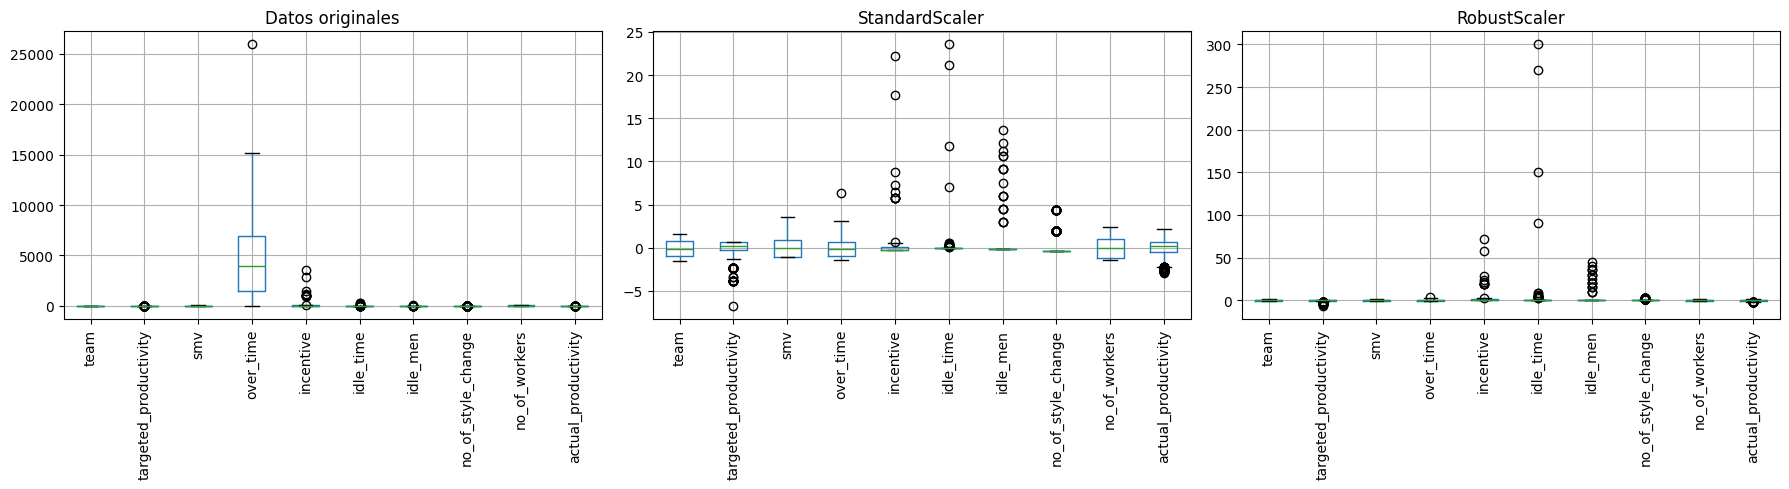

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_codificado[variables_numericas].boxplot(ax=axes[0], rot=90)
axes[0].set_title("Datos originales")

pd.DataFrame(datos_standard, columns=variables_numericas).boxplot(ax=axes[1], rot=90)
axes[1].set_title("StandardScaler")

pd.DataFrame(datos_robust, columns=variables_numericas).boxplot(ax=axes[2], rot=90)
axes[2].set_title("RobustScaler")

plt.tight_layout()
plt.show()

### Interpretación: elección del escalador

La comparación confirma lo anticipado: `StandardScaler` es sensible a los outliers detectados en `over_time`, `incentive` e `idle_time`/`idle_men`, ya que estos distorsionan la media y la desviación estándar utilizadas para el cálculo, comprimiendo artificialmente la mayoría de los valores "normales" hacia un rango muy estrecho alrededor de 0.

`RobustScaler`, al utilizar la mediana y el rango intercuartílico (IQR) (estadísticos no afectados por valores extremos), preserva mejor la proporción real del 50% central de los datos en cada variable. Si bien los outliers siguen apareciendo con magnitudes grandes en la escala robusta, esto es el comportamiento esperado. En la Fase III se decidió conservar los outliers de `wip`, `over_time` e `incentive` por representar variabilidad real del proceso productivo, por lo que interesa un escalador que no permita que esos valores extremos distorsionen la escala del resto del dataset.

**Decisión:** se utilizará `RobustScaler` como escalador final, ya que es coherente con la decisión previa de conservar los outliers sin eliminarlos ni suavizarlos, y ofrece una representación más fiel de la distribución típica de cada variable.

In [ ]:
# Aplicación final del escalador elegido: RobustScaler
df_codificado[variables_numericas] = robust_scaler.fit_transform(df_codificado[variables_numericas])

df_codificado[variables_numericas].head()

,team,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,0.333333,0.5,0.536417,0.565217,1.96,0.0,0.0,0.0,0.520833,0.837189
1,-0.833333,0.0,-0.557087,-0.543478,0.00,0.0,0.0,0.0,-0.541667,0.565988
2,0.833333,0.5,-0.189469,-0.054348,1.00,0.0,0.0,0.0,-0.072917,0.136223
3,1.000000,0.5,-0.189469,-0.054348,1.00,0.0,0.0,0.0,-0.072917,0.136223
4,0.000000,0.5,0.523622,-0.369565,1.00,0.0,0.0,0.0,0.458333,0.135280


### 4.3 Transformación de variables

La variable date se transformará al formato de fecha para facilitar su análisis. Además, se conservarán las variables categóricas originales para el análisis exploratorio.

In [ ]:
df_codificado["date"] = pd.to_datetime(df_codificado["date"])

df_codificado[["date", "quarter", "department_sweing", "day_Saturday"]].head()

,date,quarter,department_sweing,day_Saturday
0,2015-01-01,1,True,False
1,2015-01-01,1,False,False
2,2015-01-01,1,True,False
3,2015-01-01,1,True,False
4,2015-01-01,1,True,False


### Interpretación

La variable `date` fue convertida correctamente al formato de fecha, lo que permite realizar análisis relacionados con el tiempo. Las variables categóricas `quarter`, `department` y `day` ya fueron transformadas en la sección 4.2 (codificación) y se conservan en su forma numérica/binaria dentro de `df_codificado` para su uso en el resto del pipeline.

### 4.4 Ingeniería de características

A partir de la variable date se creará la variable month, que permitirá analizar posibles diferencias en la productividad según el mes de registro.

In [ ]:
df_codificado["month"] = df_codificado["date"].dt.month

df_codificado[["date", "month"]].head()

,date,month
0,2015-01-01,1
1,2015-01-01,1
2,2015-01-01,1
3,2015-01-01,1
4,2015-01-01,1


## 5. Comparación antes y después de la limpieza

Se compararán las principales características del conjunto de datos antes y después de las transformaciones realizadas.

In [ ]:
df[["targeted_productivity", "smv", "over_time", "incentive",
    "idle_time", "idle_men", "no_of_style_change",
    "no_of_workers", "actual_productivity"]].describe()

,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,0.729632,15.062172,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,0.097891,10.943219,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,0.070000,2.900000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,0.700000,3.940000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,0.750000,15.260000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,0.800000,24.260000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,0.800000,54.560000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


## 5.1 Comparación de variables categóricas

In [ ]:
df["department"].value_counts()

,count
department,
sweing,691
finishing,506


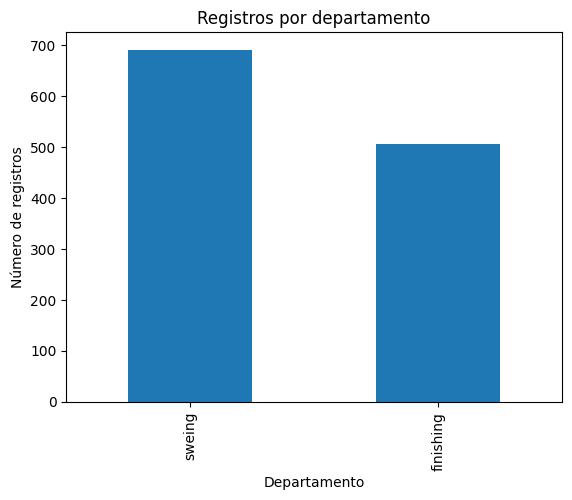

In [ ]:
df["department"].value_counts().plot(kind="bar")

plt.title("Registros por departamento")
plt.xlabel("Departamento")
plt.ylabel("Número de registros")

plt.show()

### Interpretación

El departamento de sewing concentra 691 registros, mientras que finishing cuenta con 506. Por lo tanto, el conjunto de datos tiene una mayor representación del departamento de sewing.

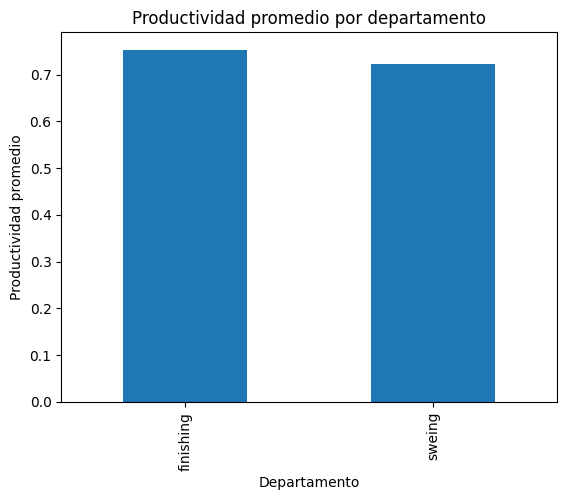

In [ ]:
df.groupby("department")["actual_productivity"].mean().plot(kind="bar")

plt.title("Productividad promedio por departamento")
plt.xlabel("Departamento")
plt.ylabel("Productividad promedio")

plt.show()

### Interpretación

La productividad promedio es similar entre ambos departamentos. Finishing presenta un promedio aproximado de 0.75, mientras que sewing presenta un promedio aproximado de 0.72.

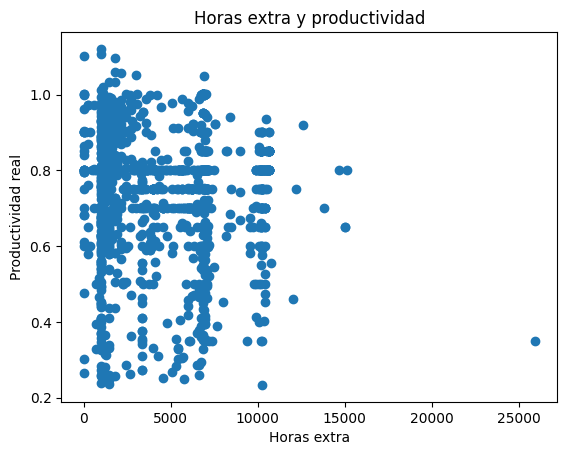

In [ ]:
plt.scatter(df["over_time"], df["actual_productivity"])

plt.title("Horas extra y productividad")
plt.xlabel("Horas extra")
plt.ylabel("Productividad real")

plt.show()

### Interpretación

La productividad presenta una alta variabilidad para distintos niveles de horas extra. No se observa una relación lineal clara entre las horas extra y la productividad real.

## 5.2 Comparación de asimetría (skewness) y curtosis

Además de las estadísticas descriptivas básicas, se comparan la asimetría (skewness) y la curtosis de cada variable numérica antes y después del pipeline de limpieza y transformación. La asimetría indica qué tan simétrica es la distribución respecto a su media (0 = simétrica), mientras que la curtosis mide qué tan "pesadas" son las colas de la distribución en comparación con una distribución normal (0 = normal, valores altos indican más outliers).

In [ ]:
comparacion_forma = pd.DataFrame({
    "Skewness_antes": df[variables_numericas].skew(),
    "Curtosis_antes": df[variables_numericas].kurtosis(),
    "Skewness_despues": df_codificado[variables_numericas].skew(),
    "Curtosis_despues": df_codificado[variables_numericas].kurtosis(),
})

comparacion_forma

,Skewness_antes,Curtosis_antes,Skewness_despues,Curtosis_despues
team,0.009848,-1.223906,0.009848,-1.223906
targeted_productivity,-2.144150,5.613701,-2.144150,5.613701
smv,0.405937,-0.795346,0.405937,-0.795346
over_time,0.673287,0.424364,0.673287,0.424364
incentive,15.790746,299.032462,15.790746,299.032462
idle_time,20.545425,442.638160,20.545425,442.638160
idle_men,9.855079,102.962869,9.855079,102.962869
no_of_style_change,2.942506,8.181490,2.942506,8.181490
no_of_workers,-0.111740,-1.788108,-0.111740,-1.788108
actual_productivity,-0.807492,0.333227,-0.807492,0.333227


### Interpretación

La comparación muestra que la asimetría (skewness) y la curtosis se mantienen prácticamente iguales antes y después del escalado. Esto es un resultado esperado: `RobustScaler` es una transformación lineal (resta la mediana y divide por el IQR), por lo que no cambia la forma de la distribución, únicamente su escala. Variables como `incentive` e `idle_time`, que ya mostraban alta asimetría y curtosis en los datos originales (consistente con los outliers detectados en la Fase III), conservan ese mismo comportamiento después de la transformación.

Esto confirma que el escalado cumplió su propósito de homogeneizar las escalas sin alterar artificialmente la distribución real de los datos ni "esconder" los outliers que se decidió conservar.

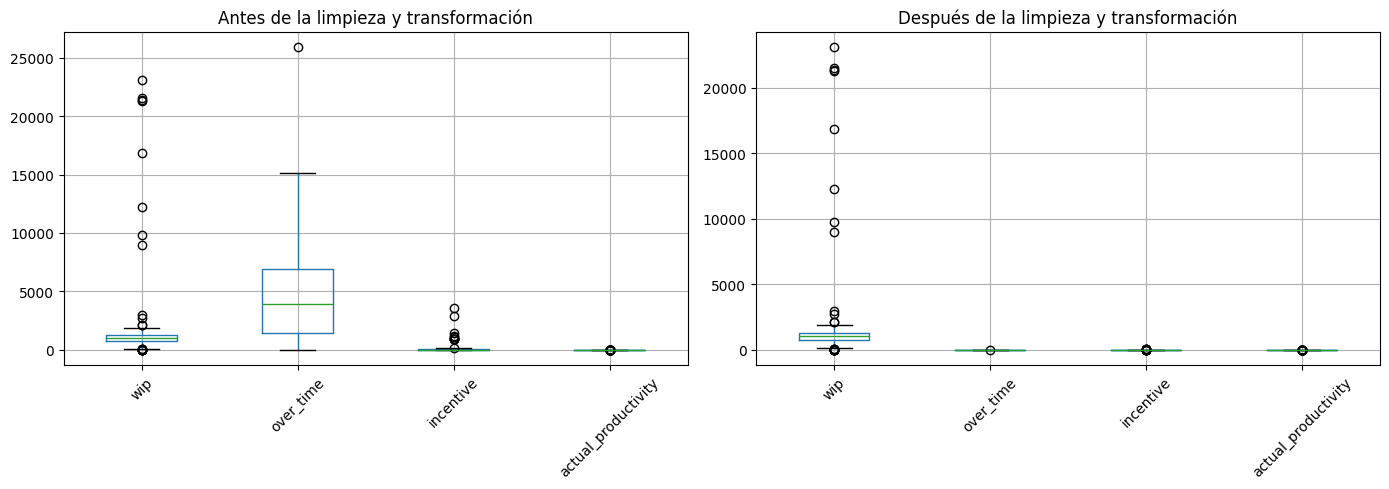

In [ ]:
variables_clave = ["wip", "over_time", "incentive", "actual_productivity"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[variables_clave].boxplot(ax=axes[0], rot=45)
axes[0].set_title("Antes de la limpieza y transformación")

df_codificado[variables_clave].boxplot(ax=axes[1], rot=45)
axes[1].set_title("Después de la limpieza y transformación")

plt.tight_layout()
plt.show()

### Interpretación del boxplot comparativo

El boxplot confirma el efecto del escalado en `over_time`, `incentive` y `actual_productivity`: después de la transformación, sus valores quedan en una escala mucho más reducida y comparable entre sí, aunque los outliers siguen presentes (como se esperaba, ya que `RobustScaler` no elimina valores atípicos, solo cambia la escala de referencia).

`wip`, en cambio, se observa igual en ambos gráficos porque no fue incluida en el proceso de escalado, ya que en la sección 3.2.1 se decidió conservar sus 506 valores faltantes sin imputar, tratándolos como una ausencia estructural del departamento `finishing`. Escalar una variable con más del 40% de valores nulos distorsionaría los estadísticos (media, mediana, IQR) usados por cualquier escalador, por lo que se excluyó intencionalmente de este paso hasta definir un tratamiento específico para sus valores ausentes.

## 6. Visualización de resultados y hallazgos finales

In [ ]:
comparacion = pd.DataFrame({
    "Aspecto": [
        "Número de registros",
        "Número de columnas",
        "Valores faltantes en WIP",
        "Formato de date",
        "Variables categóricas codificadas",
        "Outliers detectados (WIP / over_time / incentive)",
        "Escalador aplicado"
    ],
    "Antes": [
        1197,
        15,
        506,
        "Texto",
        "No",
        "22 / 1 / 11",
        "Ninguno"
    ],
    "Después": [
        df_codificado.shape[0],
        df_codificado.shape[1],
        df_codificado["wip"].isnull().sum(),
        str(df_codificado["date"].dtype),
        "Sí (One-Hot + Ordinal)",
        "Conservados (variabilidad real)",
        "RobustScaler"
    ]
})

comparacion

,Aspecto,Antes,Después
0,Número de registros,1197,1197
1,Número de columnas,15,20
2,Valores faltantes en WIP,506,506
3,Formato de date,Texto,datetime64[ns]
4,Variables categóricas codificadas,No,Sí (One-Hot + Ordinal)
5,Outliers detectados (WIP / over_time / incentive),22 / 1 / 11,Conservados (variabilidad real)
6,Escalador aplicado,Ninguno,RobustScaler


### Interpretación

La limpieza y transformación conservaron los 1,197 registros originales, y el número de columnas aumentó de 15 a 20 debido a la codificación de `department` y `day` (One-Hot Encoding) y la creación de la variable `month`. Los 506 valores faltantes de `wip` se conservaron intencionalmente, al corresponder a una ausencia estructural del departamento `finishing`, y por esta misma razón se excluyó del proceso de escalado.

Se detectaron y conservaron 22, 1 y 11 valores atípicos en `wip`, `over_time` e `incentive` respectivamente, al no encontrarse evidencia de errores de registro. Se eligió `RobustScaler` sobre `StandardScaler` como escalador final, ya que es coherente con la decisión de conservar dichos outliers sin que estos distorsionen la escala del resto de las variables.

## Conclusiones

El conjunto de datos presenta información sobre la productividad de equipos de trabajadores en una empresa de confección. Durante el análisis se identificaron valores faltantes en `wip`, así como valores atípicos en `wip`, `over_time` e `incentive`, e inconsistencias de formato en la variable `department`.

Los registros duplicados fueron inexistentes, por lo que no fue necesario eliminarlos. Los valores faltantes de `wip` se conservaron al corresponder a una ausencia estructural asociada al departamento `finishing`, y los valores atípicos identificados se conservaron en todas las variables al no encontrarse evidencia de errores de registro, considerándose parte de la variabilidad real del proceso productivo.

Las variables categóricas `department`, `day` y `quarter` fueron codificadas mediante One-Hot Encoding y codificación ordinal, respectivamente, dejando el dataset listo para su uso en modelos predictivos. Se comparó `StandardScaler` contra `RobustScaler`, seleccionando este último por su menor sensibilidad a los outliers conservados. El análisis de correlación, complementado con el coeficiente de Spearman, reveló que variables como `wip` e `incentive` tienen una asociación con la productividad más fuerte de lo que sugería únicamente la correlación de Pearson, indicando relaciones monótonas no estrictamente lineales.

Finalmente, se transformó la variable `date` al formato datetime y se creó la variable `month` para facilitar el análisis temporal. Como trabajo futuro, se recomienda evaluar modelos no lineales (como árboles de decisión o ensambles) que puedan aprovechar mejor las relaciones monótonas identificadas, y definir una estrategia específica para el uso de `wip` en el departamento `finishing` (por ejemplo, mediante una variable indicadora de ausencia) si se requiere incluirla en un modelo predictivo.

In [ ]:
df_codificado.to_csv("garments_worker_productivity_clean.csv", index=False)
print(f"Dataset exportado: {df_codificado.shape[0]} filas x {df_codificado.shape[1]} columnas")

Dataset exportado: 1197 filas x 20 columnas


In [ ]:
import subprocess

librerias = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "scipy"]
resultado = subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout.splitlines()

with open("requirements.txt", "w") as f:
    for linea in resultado:
        nombre = linea.split("==")[0].lower()
        if nombre in [lib.lower() for lib in librerias]:
            f.write(linea + "\n")

print(open("requirements.txt").read())

matplotlib==3.10.0
numpy==2.1.3
pandas==2.2.3
scikit-learn==1.6.1
scipy==1.16.3
seaborn==0.13.2

